# Эксперимент 18: Оценка ER (bge-m3) через ГА-кластеризацию

Вместо классического threshold-поиска (exp 10) кластеризуем row-эмбеддинги двумя
способами и подбираем их параметры генетическим алгоритмом ([DEAP](https://github.com/DEAP/deap)):

1. **HDBSCAN + ГА** — density-кластеризация. Пространство поиска сужено
   под ER-приор (`min_cluster_size ∈ [2, 5]`, `min_samples ∈ [1, 5]`):
   дубликаты обычно образуют пары, а не группы по сотням.
2. **Connected Components + ГА** — рёбра графа `sim ≥ τ` среди top-K cos-NN,
   кластеры = компоненты связности. Гены: `tau ∈ [0.5, 0.999]`, `top_k ∈ [1, top_k_max]`.

**Правило на парах** (одинаковое для обоих):

```
match(a, b) ⇔ cluster[a] == cluster[b]   и   cluster[a] != noise
```

Для HDBSCAN `noise = -1` (точки, не попавшие в кластер). Для CC шума нет — каждая
строка обязательно в каком-то компоненте; синглтоны просто не дают совпадений.

**Фитнес-функция (общая, см. `evaluation/ga_common.py`):**

* **F-beta** на val_pairs (β = 1 по умолчанию). β < 1 наказывает FP сильнее —
  актуально для ER, где ложные совпадения дороже пропущенных.
* **Penalty за «гигантский кластер»**: если максимальный non-noise кластер
  покрывает > 50% всех строк, F-beta домножается на 0.5. Защита от вырожденного
  «слить всё в один компонент», на который precision на val_pairs может реагировать
  слабо при дисбалансе.

**Бэкенды HDBSCAN:** `cpu` — пакет `hdbscan`, `gpu` — `cuml.cluster.HDBSCAN` (RAPIDS).
`auto` = gpu при наличии cuml.

**Артефакты ожидаются в** `data/graphs/bge-m3/v14_mrl/` + `output/bge-m3/v14_mrl_gat_model.pt`
(собираются из exp 14 / 16 для tag `bge-m3`).

> **Важно.** Чтобы `PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True` подхватился, 
запусти kernel заново **до** импорта `torch` (или поставь переменную в shell перед `jupyter lab`). 
Первая ячейка ниже ставит её через `os.environ.setdefault` — работает, только если 
`torch` ещё не импортирован в этом kernel.

## 1. Импорты и конфиг

In [1]:
import os
# expandable_segments должен быть установлен ДО первого импорта torch;
# после изменения значения перезапусти kernel.
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import gc
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

plt.rcParams.update({
    'figure.figsize': (11, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

MODEL_TAG = 'rubert-tiny2'
GRAPH_SUBDIR = 'v14_mrl'
CROSS_SUBDIR = 'v14_mrl_cross'
MODEL_FILENAME = 'v14_mrl_gat_model.pt'
BACKEND = 'auto'

DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'output'
GRAPH_DIR = DATA_DIR / 'graphs' / MODEL_TAG / GRAPH_SUBDIR
CROSS_DIR = DATA_DIR / 'graphs' / MODEL_TAG / CROSS_SUBDIR
MODEL_PATH = OUTPUT_DIR / MODEL_TAG / MODEL_FILENAME

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', device)
print('PYTORCH_CUDA_ALLOC_CONF =', os.environ.get('PYTORCH_CUDA_ALLOC_CONF'))
if device == 'cuda':
    free, total = torch.cuda.mem_get_info()
    print(f'GPU free / total : {free / 1e9:.2f} / {total / 1e9:.2f} GB')
print('graph =', GRAPH_DIR)
print('model =', MODEL_PATH)

device = cuda
PYTORCH_CUDA_ALLOC_CONF = expandable_segments:True
GPU free / total : 77.43 / 84.99 GB
graph = /home/user/Lysenko/Diplom/TableUnifier/data/graphs/rubert-tiny2/v14_mrl
model = /home/user/Lysenko/Diplom/TableUnifier/output/rubert-tiny2/v14_mrl_gat_model.pt


## 2. Загрузка графа, пар и модели

In [2]:
from table_unifier.evaluation.clustering import (
    evaluate_pairs_at_threshold,
    evaluate_pairs_auc,
    find_best_threshold,
)
from table_unifier.evaluation.ga_hdbscan import (
    GAHDBSCANConfig,
    evaluate_params_on_pairs,
    resolve_backend,
    run_ga_hdbscan,
)
from table_unifier.evaluation.ga_cc import (
    GACCConfig,
    evaluate_params_on_pairs_cc,
    run_ga_cc,
)
from table_unifier.models.entity_resolution import EntityResolutionGAT
from table_unifier.training.er_trainer import get_row_embeddings

graph = torch.load(GRAPH_DIR / 'graph.pt', weights_only=False)
val_pairs = torch.load(GRAPH_DIR / 'val_pairs.pt', weights_only=False)
test_pairs = torch.load(GRAPH_DIR / 'test_pairs.pt', weights_only=False)

print('rows   :', graph['row'].x.shape[0])
print('tokens :', graph['token'].x.shape[0])
print('edges  :', graph['token', 'in_row', 'row'].edge_index.shape[1])
print('col_dim:', graph.col_embeddings.shape[1])
print(f'val={len(val_pairs)} pairs, test={len(test_pairs)} pairs')

cfg_path = MODEL_PATH.with_suffix('.config.json')
with open(cfg_path) as f:
    cfg = json.load(f)
cfg

rows   : 341053
tokens : 19833
edges  : 9280687
col_dim: 312
val=1020 pairs, test=1019 pairs


{'row_dim': 312,
 'token_dim': 312,
 'col_dim': 312,
 'hidden_dim': 312,
 'edge_dim': 312,
 'output_dim': 312,
 'num_gnn_layers': 2,
 'num_heads': 4,
 'dropout': 0.3,
 'attention_dropout': 0.1,
 'bidirectional': True,
 'use_input_projection': False,
 'graph_subdir': 'v14_mrl'}

In [3]:
def build_model(cfg: dict) -> EntityResolutionGAT:
    return EntityResolutionGAT(
        row_dim=cfg['row_dim'], token_dim=cfg['token_dim'], col_dim=cfg['col_dim'],
        hidden_dim=cfg['hidden_dim'], edge_dim=cfg['edge_dim'], output_dim=cfg['output_dim'],
        num_gnn_layers=cfg['num_gnn_layers'], num_heads=cfg['num_heads'],
        dropout=cfg['dropout'], attention_dropout=cfg['attention_dropout'],
        bidirectional=cfg['bidirectional'],
        use_input_projection=cfg.get('use_input_projection', False),
    )

def _free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def safe_get_row_embeddings(model_fp32, graph, *, use_fp16=True):
    '''GPU inference with fp16 + OOM → CPU fallback.

    NB: HeteroData.to() / .clone() в PyG расшаривают tensor stores; чтобы
    in-place .half() в fp16-ветке не «утекал» обратно в исходный fp32-граф
    (что ломает CPU fallback), берём свежий клон до любых модификаций.
    '''
    _free_gpu()
    if device == 'cuda':
        try:
            if use_fp16:
                m = build_model(cfg).half().to(device)
                m.load_state_dict({k: v.half() for k, v in state.items()})
                m.eval()
                # clone() даёт независимые тензоры, .to(device) их не разделит обратно
                g = graph.clone().to(device)
                for store in [g['row'], g['token']]:
                    if hasattr(store, 'x') and store.x.is_floating_point():
                        store.x = store.x.half()
                if hasattr(g, 'col_embeddings') and g.col_embeddings.is_floating_point():
                    g.col_embeddings = g.col_embeddings.half()
                with torch.inference_mode():
                    emb = m(g).float().cpu()
                del m, g
                _free_gpu()
                return emb
            else:
                m = model_fp32.to(device).eval()
                with torch.inference_mode():
                    return get_row_embeddings(m, graph, device=device).cpu()
        except torch.cuda.OutOfMemoryError as e:
            print(f'[WARN] GPU OOM ({e}); откатываемся на CPU')
            _free_gpu()
    # CPU fallback — graph остался fp32 (мутировали только клон выше).
    m = model_fp32.float().cpu().eval()
    with torch.inference_mode():
        return get_row_embeddings(m, graph, device='cpu').cpu()

model = build_model(cfg)
state = torch.load(MODEL_PATH, map_location='cpu', weights_only=True)
model.load_state_dict(state)
model.eval()

embeddings = safe_get_row_embeddings(model, graph, use_fp16=True)
embeddings_np = embeddings.detach().cpu().numpy()
print('embeddings:', embeddings.shape, '| mean norm =', float(embeddings.norm(dim=1).mean()))
if device == 'cuda':
    free, total = torch.cuda.mem_get_info()
    print(f'GPU free / total : {free / 1e9:.2f} / {total / 1e9:.2f} GB')

embeddings: torch.Size([341053, 312]) | mean norm = 1.0000054836273193
GPU free / total : 77.16 / 84.99 GB


## 3. Baseline — threshold (как exp 10)

In [4]:
thr, val_f1 = find_best_threshold(embeddings, val_pairs)

val_thr = evaluate_pairs_at_threshold(embeddings, val_pairs, thr)
val_thr.update(evaluate_pairs_auc(embeddings, val_pairs))

test_thr = evaluate_pairs_at_threshold(embeddings, test_pairs, thr)
test_thr.update(evaluate_pairs_auc(embeddings, test_pairs))

print(f'optimal θ = {thr:.4f}')
pd.DataFrame({'val': val_thr, 'test': test_thr}).T

optimal θ = 0.9959


,threshold,f1,precision,recall,n_pairs,n_pos,n_predicted_pos,roc_auc,avg_precision
val,0.995855,0.822709,0.822709,0.822709,1020.0,502.0,502.0,0.894026,0.903024
test,0.995855,0.794148,0.829694,0.761523,1019.0,499.0,458.0,0.900580,0.898925


## 4. GA-HDBSCAN

Bounds сужены под ER-приор: `min_cluster_size ∈ [2, 5]`, `min_samples ∈ [1, 5]`.
Большие `mcs` для дубликатов вырождают кластеризацию (всё уходит в шум `-1` → recall=0).
Если `BACKEND='auto'` — бэкенд подбирается автоматически (gpu при наличии `cuml`, иначе cpu).
Фитнес — F-beta + penalty за гигантский кластер (см. `GAHDBSCANConfig.fbeta` /
`giant_cluster_threshold`). Для релизного прогона увеличь `pop_size`/`n_gen`.

In [5]:
print('resolved backend =', resolve_backend(BACKEND))

ga_cfg = GAHDBSCANConfig(
    pop_size=30,
    n_gen=20,
    cxpb=0.6,
    mutpb=0.4,
    tournament_size=3,
    # ER-приор: дубликаты — пары/тройки. Шире — recall обрушается в 0.
    min_cluster_size_bounds=(2, 5),
    min_samples_bounds=(1, 5),
    epsilon_bounds=(0.0, 1.0),
    seed=42,
    n_jobs=4,
    backend=BACKEND,
    # Фитнес. β=1 → честная F1; β=0.5 если хочется precision-leaning.
    fbeta=1.0,
    giant_cluster_threshold=0.5,
    giant_cluster_penalty=0.5,
)
ga = run_ga_hdbscan(embeddings, val_pairs, ga_cfg)
print('best params :', ga.best_params)
print(f'best val fitness : {ga.best_fitness:.4f}')
print(f'unique evals: {ga.n_evaluated} / {ga_cfg.pop_size * (ga_cfg.n_gen + 1)}')

resolved backend = gpu
best params : {'min_cluster_size': 2, 'min_samples': 1, 'cluster_selection_epsilon': 0.06873572185284103, 'cluster_selection_method': 'eom', 'metric': 'cosine'}
best val fitness : 0.7034
unique evals: 183 / 630


### Сходимость ГА

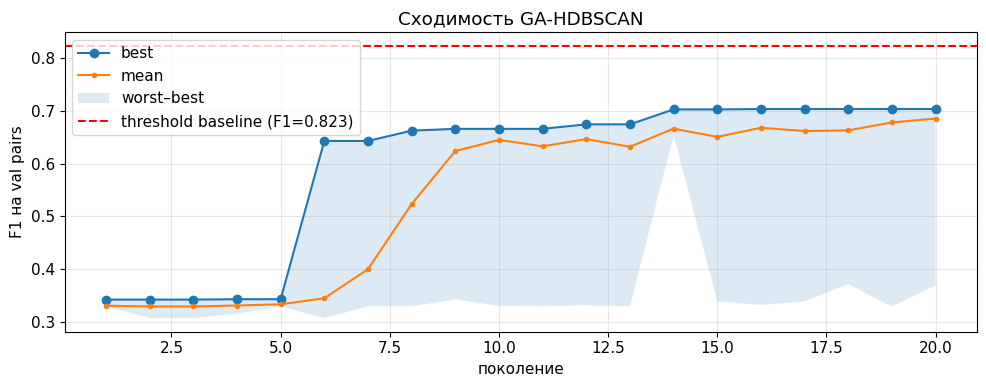

,gen,best_f1,mean_f1,worst_f1,n_cached
0,1,0.342668,0.331113,0.329829,46
1,2,0.342668,0.329650,0.307878,63
2,3,0.342668,0.329650,0.307878,82
3,4,0.343405,0.331462,0.316233,97
4,5,0.343405,0.333778,0.329829,104
5,6,0.642857,0.345188,0.307631,114
6,7,0.642857,0.400096,0.329829,118
7,8,0.662371,0.523255,0.329829,128
8,9,0.665810,0.623795,0.343152,136
9,10,0.665810,0.644798,0.330683,140


In [6]:
hist = pd.DataFrame(ga.history)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist['gen'], hist['best_f1'], marker='o', label='best')
ax.plot(hist['gen'], hist['mean_f1'], marker='.', label='mean')
ax.fill_between(hist['gen'], hist['worst_f1'], hist['best_f1'], alpha=0.15, label='worst–best')
ax.axhline(val_f1, color='red', ls='--', label=f'threshold baseline (F1={val_f1:.3f})')
ax.set_xlabel('поколение')
ax.set_ylabel('F1 на val pairs')
ax.set_title('Сходимость GA-HDBSCAN')
ax.legend()
plt.tight_layout()
plt.show()
hist

## 5. Метрики с лучшими параметрами

In [7]:
val_ga = evaluate_params_on_pairs(embeddings_np, val_pairs, ga.best_params,
                                  n_jobs=ga_cfg.n_jobs, backend=ga.backend)
test_ga = evaluate_params_on_pairs(embeddings_np, test_pairs, ga.best_params,
                                   n_jobs=ga_cfg.n_jobs, backend=ga.backend)

print('val :', val_ga)
print('test:', test_ga)

pd.DataFrame({
    'threshold (val)': val_thr,
    'GA-HDBSCAN (val)': val_ga,
    'threshold (test)': test_thr,
    'GA-HDBSCAN (test)': test_ga,
}).T[['f1', 'precision', 'recall']].round(4)

val : {'f1': 0.705607476635514, 'precision': 0.8531073446327684, 'recall': 0.601593625498008, 'n_clusters': 53187, 'n_noise': 98924, 'n_pairs': 1020, 'n_pos': 502, 'n_predicted_pos': 354}
test: {'f1': 0.6911242603550296, 'precision': 0.8439306358381503, 'recall': 0.5851703406813628, 'n_clusters': 53222, 'n_noise': 98889, 'n_pairs': 1019, 'n_pos': 499, 'n_predicted_pos': 346}


,f1,precision,recall
threshold (val),0.8227,0.8227,0.8227
GA-HDBSCAN (val),0.7056,0.8531,0.6016
threshold (test),0.7941,0.8297,0.7615
GA-HDBSCAN (test),0.6911,0.8439,0.5852


### Визуализация сравнения

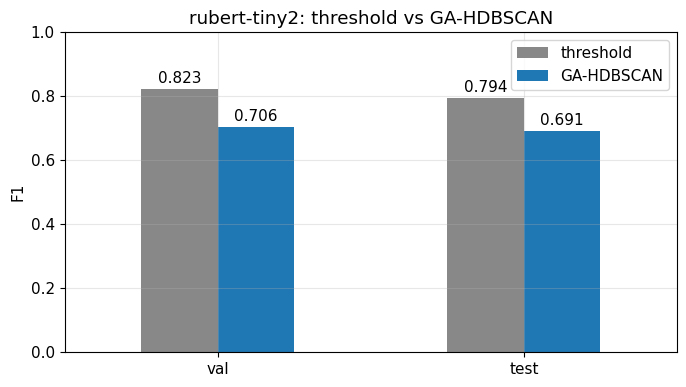

In [8]:
comp = pd.DataFrame({
    'threshold': [val_thr.get('f1', 0), test_thr.get('f1', 0)],
    'GA-HDBSCAN': [val_ga.get('f1', 0), test_ga.get('f1', 0)],
}, index=['val', 'test'])

ax = comp.plot(kind='bar', figsize=(7, 4), rot=0, color=['#888', '#1f77b4'])
ax.set_ylabel('F1')
ax.set_title(f'{MODEL_TAG}: threshold vs GA-HDBSCAN')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 6. GA-CC (Connected Components)

Альтернатива HDBSCAN, ближе к природе ER: рёбра графа `sim ≥ τ` среди top-K cos-NN,
кластеры = компоненты связности. ГА подбирает `(τ, top_k)`. Для пар-дубликатов
оптимум обычно `top_k=1`; большие top_k допускают группы из 3+ элементов.

Top-K матрица соседей считается один раз, поэтому ГА здесь дёшев — увеличить
`pop_size`/`n_gen` можно почти бесплатно.

In [9]:
ga_cc_cfg = GACCConfig(
    pop_size=30,
    n_gen=20,
    cxpb=0.6,
    mutpb=0.4,
    tournament_size=3,
    tau_bounds=(0.5, 0.999),
    top_k_max=10,
    seed=42,
    fbeta=1.0,
    giant_cluster_threshold=0.5,
    giant_cluster_penalty=0.5,
)
ga_cc = run_ga_cc(embeddings_np, val_pairs, ga_cc_cfg)
print('best params :', ga_cc.best_params)
print(f'best val fitness : {ga_cc.best_fitness:.4f}')
print(f'unique evals: {ga_cc.n_evaluated} / {ga_cc_cfg.pop_size * (ga_cc_cfg.n_gen + 1)}')

best params : {'tau': 0.819073972430484, 'top_k': 1}
best val fitness : 0.7324
unique evals: 161 / 630


### Сходимость GA-CC

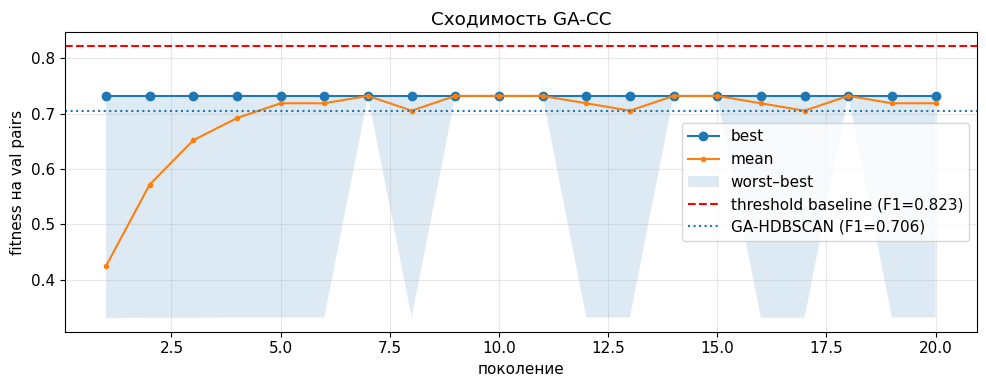

,gen,best_f1,mean_f1,worst_f1,n_cached
0,1,0.73236,0.424601,0.330464,51
1,2,0.73236,0.571961,0.330911,63
2,3,0.73236,0.652212,0.330991,71
3,4,0.73236,0.692299,0.331747,78
4,5,0.73236,0.719006,0.331747,82
5,6,0.73236,0.719006,0.331747,87
6,7,0.73236,0.732360,0.732360,91
7,8,0.73236,0.705653,0.331747,100
8,9,0.73236,0.732360,0.732360,107
9,10,0.73236,0.732360,0.732360,112


In [10]:
hist_cc = pd.DataFrame(ga_cc.history)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_cc['gen'], hist_cc['best_f1'], marker='o', label='best')
ax.plot(hist_cc['gen'], hist_cc['mean_f1'], marker='.', label='mean')
ax.fill_between(hist_cc['gen'], hist_cc['worst_f1'], hist_cc['best_f1'], alpha=0.15, label='worst–best')
ax.axhline(val_f1, color='red', ls='--', label=f'threshold baseline (F1={val_f1:.3f})')
ax.axhline(val_ga.get('f1', 0), color='#1f77b4', ls=':', label=f'GA-HDBSCAN (F1={val_ga.get("f1", 0):.3f})')
ax.set_xlabel('поколение')
ax.set_ylabel('fitness на val pairs')
ax.set_title('Сходимость GA-CC')
ax.legend()
plt.tight_layout()
plt.show()
hist_cc

### Метрики GA-CC и общее сравнение всех методов

In [11]:
val_cc = evaluate_params_on_pairs_cc(embeddings_np, val_pairs, ga_cc.best_params)
test_cc = evaluate_params_on_pairs_cc(embeddings_np, test_pairs, ga_cc.best_params)

print('val :', val_cc)
print('test:', test_cc)

summary = pd.DataFrame({
    'threshold (val)': val_thr,
    'GA-HDBSCAN (val)': val_ga,
    'GA-CC (val)': val_cc,
    'threshold (test)': test_thr,
    'GA-HDBSCAN (test)': test_ga,
    'GA-CC (test)': test_cc,
}).T[['f1', 'precision', 'recall']].round(4)
summary

val : {'f1': 0.732360097323601, 'precision': 0.940625, 'recall': 0.599601593625498, 'n_clusters': 75466, 'n_noise': 0, 'n_pairs': 1020, 'n_pos': 502, 'n_predicted_pos': 320}
test: {'f1': 0.7169811320754716, 'precision': 0.9628378378378378, 'recall': 0.5711422845691383, 'n_clusters': 75466, 'n_noise': 0, 'n_pairs': 1019, 'n_pos': 499, 'n_predicted_pos': 296}


,f1,precision,recall
threshold (val),0.8227,0.8227,0.8227
GA-HDBSCAN (val),0.7056,0.8531,0.6016
GA-CC (val),0.7324,0.9406,0.5996
threshold (test),0.7941,0.8297,0.7615
GA-HDBSCAN (test),0.6911,0.8439,0.5852
GA-CC (test),0.7170,0.9628,0.5711


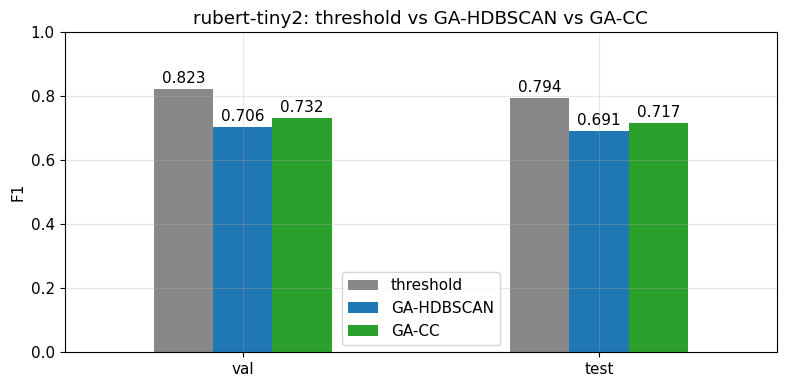

In [12]:
comp_all = pd.DataFrame({
    'threshold':   [val_thr.get('f1', 0), test_thr.get('f1', 0)],
    'GA-HDBSCAN':  [val_ga.get('f1', 0),  test_ga.get('f1', 0)],
    'GA-CC':       [val_cc.get('f1', 0),  test_cc.get('f1', 0)],
}, index=['val', 'test'])

ax = comp_all.plot(kind='bar', figsize=(8, 4), rot=0,
                   color=['#888', '#1f77b4', '#2ca02c'])
ax.set_ylabel('F1')
ax.set_title(f'{MODEL_TAG}: threshold vs GA-HDBSCAN vs GA-CC')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. Cross-domain (те же ГА-параметры для обоих методов)

Используем `ga.best_params` для HDBSCAN и `ga_cc.best_params` для CC, найденные
на main-датасете, и переоцениваем на каждом cross-domain датасете без переобучения
ГА. Это проверяет переносимость.

In [13]:
cross_rows = []
if CROSS_DIR.exists():
    for ds_dir in sorted(CROSS_DIR.iterdir()):
        lp_path = ds_dir / 'labeled_pairs.pt'
        if not ds_dir.is_dir() or not (ds_dir / 'graph.pt').exists() or not lp_path.exists():
            continue
        name = ds_dir.name
        cg = torch.load(ds_dir / 'graph.pt', weights_only=False)
        cd_model = build_model(cfg)
        cd_model.load_state_dict(state)
        cd_model.eval()

        cd_emb_t = safe_get_row_embeddings(cd_model, cg, use_fp16=True)
        cd_emb = cd_emb_t.detach().cpu().numpy()
        labeled = torch.load(lp_path, weights_only=False)

        cd_thr = evaluate_pairs_at_threshold(torch.from_numpy(cd_emb), labeled, thr)
        cd_thr.update(evaluate_pairs_auc(torch.from_numpy(cd_emb), labeled))
        cd_hdb = evaluate_params_on_pairs(cd_emb, labeled, ga.best_params,
                                          n_jobs=ga_cfg.n_jobs, backend=ga.backend)
        cd_cc = evaluate_params_on_pairs_cc(cd_emb, labeled, ga_cc.best_params)

        cross_rows.append({
            'dataset': name,
            'n_pairs': int(len(labeled)),
            'thr_f1': cd_thr.get('f1', 0.0),
            'hdb_f1': cd_hdb.get('f1', 0.0),
            'hdb_precision': cd_hdb.get('precision', 0.0),
            'hdb_recall': cd_hdb.get('recall', 0.0),
            'hdb_clusters': cd_hdb.get('n_clusters', 0),
            'hdb_noise': cd_hdb.get('n_noise', 0),
            'cc_f1': cd_cc.get('f1', 0.0),
            'cc_precision': cd_cc.get('precision', 0.0),
            'cc_recall': cd_cc.get('recall', 0.0),
            'cc_clusters': cd_cc.get('n_clusters', 0),
        })
        del cg, cd_emb, cd_emb_t, cd_model
        _free_gpu()

cross_df = pd.DataFrame(cross_rows)
cross_df

,dataset,n_pairs,thr_f1,hdb_f1,hdb_precision,hdb_recall,hdb_clusters,hdb_noise,cc_f1,cc_precision,cc_recall,cc_clusters
0,anime,379,0.0,0.086957,1.0,0.045455,1947,2640,0.209302,1.0,0.116883,1992
1,citations,370,0.0,0.000000,0.0,0.000000,1169,3326,0.000000,0.0,0.000000,1221
2,electronics,365,0.0,0.000000,0.0,0.000000,2065,2636,0.037037,1.0,0.018868,2164


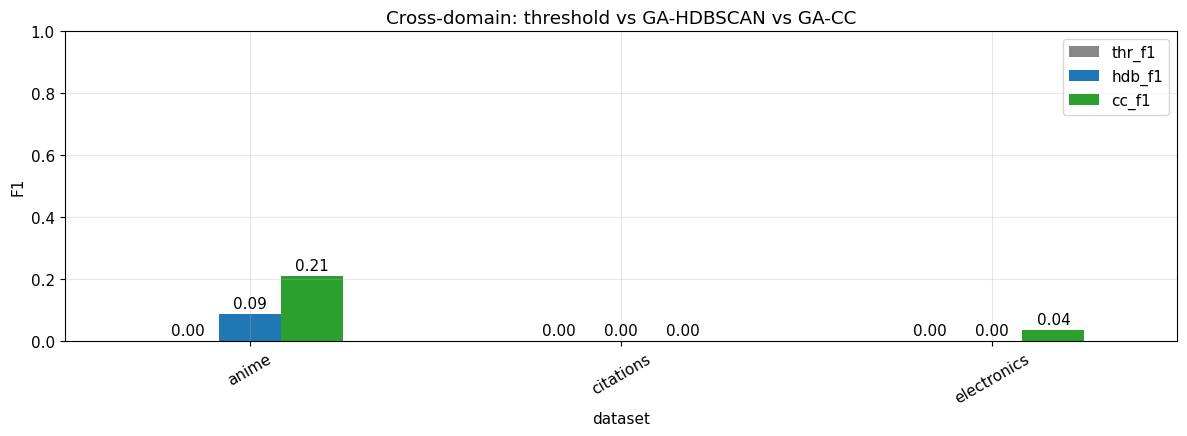

In [14]:
if not cross_df.empty:
    ax = cross_df.set_index('dataset')[['thr_f1', 'hdb_f1', 'cc_f1']].plot(
        kind='bar', figsize=(12, 4.5), rot=30,
        color=['#888', '#1f77b4', '#2ca02c'],
    )
    ax.set_ylabel('F1')
    ax.set_title('Cross-domain: threshold vs GA-HDBSCAN vs GA-CC')
    ax.set_ylim(0, 1)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f', padding=2)
    plt.tight_layout()
    plt.show()

## 8. Сохранение результатов

In [15]:
results = {
    'model_tag': MODEL_TAG,
    'model_path': str(MODEL_PATH),
    'graph_subdir': GRAPH_SUBDIR,
    'n_rows': int(embeddings.shape[0]),
    'embedding_dim': int(embeddings.shape[1]),
    'threshold_baseline': {
        'threshold': float(thr),
        'val': val_thr,
        'test': test_thr,
    },
    'ga_hdbscan': {
        'backend': ga.backend,
        'best_params': ga.best_params,
        'best_val_fitness': ga.best_fitness,
        'n_evaluated': ga.n_evaluated,
        'config': {
            'pop_size': ga_cfg.pop_size, 'n_gen': ga_cfg.n_gen,
            'cxpb': ga_cfg.cxpb, 'mutpb': ga_cfg.mutpb,
            'tournament_size': ga_cfg.tournament_size, 'seed': ga_cfg.seed,
            'min_cluster_size_bounds': list(ga_cfg.min_cluster_size_bounds),
            'min_samples_bounds': list(ga_cfg.min_samples_bounds),
            'fbeta': ga_cfg.fbeta,
            'giant_cluster_threshold': ga_cfg.giant_cluster_threshold,
            'giant_cluster_penalty': ga_cfg.giant_cluster_penalty,
        },
        'history': ga.history,
        'val': val_ga,
        'test': test_ga,
    },
    'ga_cc': {
        'best_params': ga_cc.best_params,
        'best_val_fitness': ga_cc.best_fitness,
        'n_evaluated': ga_cc.n_evaluated,
        'config': {
            'pop_size': ga_cc_cfg.pop_size, 'n_gen': ga_cc_cfg.n_gen,
            'cxpb': ga_cc_cfg.cxpb, 'mutpb': ga_cc_cfg.mutpb,
            'tournament_size': ga_cc_cfg.tournament_size, 'seed': ga_cc_cfg.seed,
            'tau_bounds': list(ga_cc_cfg.tau_bounds),
            'top_k_max': ga_cc_cfg.top_k_max,
            'fbeta': ga_cc_cfg.fbeta,
            'giant_cluster_threshold': ga_cc_cfg.giant_cluster_threshold,
            'giant_cluster_penalty': ga_cc_cfg.giant_cluster_penalty,
        },
        'history': ga_cc.history,
        'val': val_cc,
        'test': test_cc,
    },
    'cross_domain': cross_rows,
}

out_path = OUTPUT_DIR / MODEL_TAG / 'v18_ga_hdbscan_results.json'
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2, default=float)
print('saved →', out_path)

saved → /home/user/Lysenko/Diplom/TableUnifier/output/rubert-tiny2/v18_ga_hdbscan_results.json
